# Notebook 13 — Training Loss Curves
- **Data**: `/raid/ruban/hpmlproj/outputs_MLP_baseline/`
- **Figures saved to**: `/raid/ruban/hpmlproj/term_project/`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR   = Path('/raid/ruban/hpmlproj/outputs_MLP_baseline')
OUT_DIR    = Path('/raid/ruban/hpmlproj/term_project')

print('Data dir :', DATA_DIR)
print('Out dir  :', OUT_DIR)
print('CSV files found:', [f.name for f in DATA_DIR.glob('*.csv')])

Data dir : /raid/ruban/hpmlproj/outputs_MLP_baseline
Out dir  : /raid/ruban/hpmlproj/term_project
CSV files found: ['recall_results.csv', 'inference_timing.csv', 'training_timing.csv', 'multigpu_benchmark.csv']


In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
train_df = pd.read_csv(DATA_DIR / 'training_timing.csv')
multi_df = pd.read_csv(DATA_DIR / 'multigpu_benchmark.csv')
infer_df = pd.read_csv(DATA_DIR / 'inference_timing.csv', index_col='metric')['value']

print(f'Training epochs : {len(train_df)}')
print(f'Final train loss: {train_df.train_loss.iloc[-1]:.4f}')
print(f'Final val loss  : {train_df.val_loss.iloc[-1]:.4f}')
print(f'Total train time: {train_df.epoch_time_s.sum()/60:.1f} min')

Training epochs : 200
Final train loss: 4.5602
Final val loss  : 5.6255
Total train time: 11.1 min


In [3]:
# ── Derived quantities ───────────────────────────────────────────────────────
epochs      = train_df['epoch'].values
train_loss  = train_df['train_loss'].values
val_loss    = train_df['val_loss'].values
epoch_time  = train_df['epoch_time_s'].values
gpu_compute = train_df['gpu_compute_s'].values
sync_oh     = train_df['sync_overhead_s'].values
cumtime     = np.cumsum(epoch_time)

RANDOM_BASELINE = 9.01

best_val_epoch = int(val_loss.argmin()) + 1
best_val_loss  = val_loss.min()
print(f'Best val loss {best_val_loss:.4f} at epoch {best_val_epoch}')

Best val loss 5.5955 at epoch 56


Saved: /raid/ruban/hpmlproj/term_project/fig_training_dynamics.png


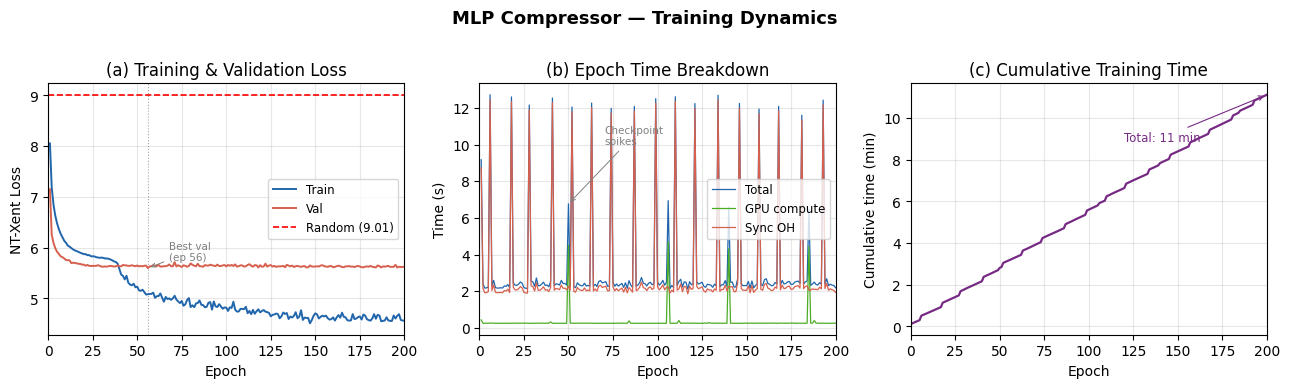

In [4]:
# ── Figure 1: Combined 3-panel ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
fig.suptitle('MLP Compressor — Training Dynamics', fontsize=13, fontweight='bold', y=1.01)

# Panel (a): Loss curves
ax = axes[0]
ax.plot(epochs, train_loss, color='#2166ac', lw=1.4, label='Train', zorder=3)
ax.plot(epochs, val_loss,   color='#d6604d', lw=1.4, label='Val',   zorder=3)
ax.axhline(RANDOM_BASELINE, color='red', lw=1.2, ls='--', label=f'Random ({RANDOM_BASELINE})')
ax.axvline(best_val_epoch, color='gray', lw=0.8, ls=':', alpha=0.7)
ax.annotate(f'Best val\n(ep {best_val_epoch})',
            xy=(best_val_epoch, best_val_loss),
            xytext=(best_val_epoch + 12, best_val_loss + 0.15),
            fontsize=7.5, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.7))
ax.set_xlabel('Epoch'); ax.set_ylabel('NT-Xent Loss')
ax.set_title('(a) Training & Validation Loss')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3); ax.set_xlim(0, len(epochs))

# Panel (b): Epoch time breakdown
ax = axes[1]
ax.plot(epochs, epoch_time,  color='#2166ac', lw=0.9, label='Total')
ax.plot(epochs, gpu_compute, color='#4dac26', lw=0.9, label='GPU compute')
ax.plot(epochs, sync_oh,     color='#d6604d', lw=0.9, label='Sync OH')
ax.set_xlabel('Epoch'); ax.set_ylabel('Time (s)')
ax.set_title('(b) Epoch Time Breakdown')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3); ax.set_xlim(0, len(epochs))
ax.annotate('Checkpoint\nspikes', xy=(50, epoch_time[49]),
            xytext=(70, 10), fontsize=7.5, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.7))

# Panel (c): Cumulative training time
ax = axes[2]
ax.plot(epochs, cumtime / 60, color='#762a83', lw=1.6)
ax.set_xlabel('Epoch'); ax.set_ylabel('Cumulative time (min)')
ax.set_title('(c) Cumulative Training Time')
ax.grid(True, alpha=0.3); ax.set_xlim(0, len(epochs))
total_min = cumtime[-1] / 60
ax.annotate(f'Total: {total_min:.0f} min',
            xy=(len(epochs), total_min),
            xytext=(len(epochs)*0.6, total_min*0.8),
            fontsize=8.5, color='#762a83',
            arrowprops=dict(arrowstyle='->', color='#762a83', lw=0.8))

plt.tight_layout()
out = str(OUT_DIR / 'fig_training_dynamics.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

Saved: /raid/ruban/hpmlproj/term_project/fig_training_loss.png


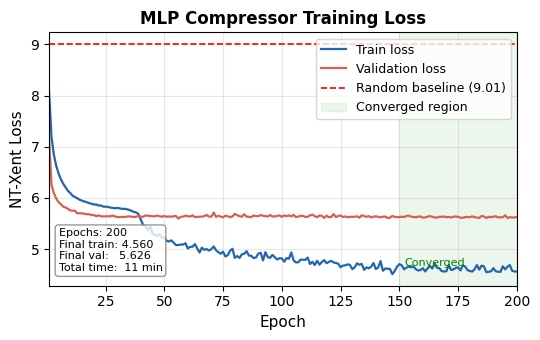

In [5]:
# ── Figure 2: Loss-only (for paper) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(epochs, train_loss, color='#2166ac', lw=1.6, label='Train loss')
ax.plot(epochs, val_loss,   color='#d6604d', lw=1.6, label='Validation loss')
ax.axhline(RANDOM_BASELINE, color='red', lw=1.2, ls='--',
           label=f'Random baseline ({RANDOM_BASELINE:.2f})')
ax.axvspan(150, 200, alpha=0.07, color='green', label='Converged region')
ax.text(152, train_loss[149:].mean() + 0.05, 'Converged', fontsize=8, color='green')
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('NT-Xent Loss', fontsize=11)
ax.set_title('MLP Compressor Training Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3); ax.set_xlim(1, len(epochs))
stats = (f'Epochs: {len(epochs)}\nFinal train: {train_loss[-1]:.3f}\n'
         f'Final val:   {val_loss[-1]:.3f}\nTotal time:  {cumtime[-1]/60:.0f} min')
ax.text(0.02, 0.05, stats, transform=ax.transAxes, fontsize=8,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
plt.tight_layout()
out = str(OUT_DIR / 'fig_training_loss.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()

In [6]:
# ── Summary table ────────────────────────────────────────────────────────────
print('=== Training Summary ===')
print(f'Total epochs          : {len(epochs)}')
print(f'Initial train loss    : {train_loss[0]:.4f}')
print(f'Final train loss      : {train_loss[-1]:.4f}')
print(f'Final val loss        : {val_loss[-1]:.4f}')
print(f'Best val loss         : {best_val_loss:.4f}  (epoch {best_val_epoch})')
print(f'Random baseline       : {RANDOM_BASELINE}')
print(f'Mean epoch time       : {epoch_time.mean():.2f} s')
print(f'Mean GPU compute/epoch: {gpu_compute.mean():.3f} s')
print(f'Mean sync OH/epoch    : {sync_oh.mean():.3f} s')
print(f'GPU compute fraction  : {gpu_compute.mean()/epoch_time.mean()*100:.1f}%')
print(f'Sync OH fraction      : {sync_oh.mean()/epoch_time.mean()*100:.1f}%')
print(f'Total training time   : {cumtime[-1]/60:.1f} min  ({cumtime[-1]/3600:.2f} h)')

=== Training Summary ===
Total epochs          : 200
Initial train loss    : 8.0518
Final train loss      : 4.5602
Final val loss        : 5.6255
Best val loss         : 5.5955  (epoch 56)
Random baseline       : 9.01
Mean epoch time       : 3.34 s
Mean GPU compute/epoch: 0.342 s
Mean sync OH/epoch    : 2.995 s
GPU compute fraction  : 10.2%
Sync OH fraction      : 89.8%
Total training time   : 11.1 min  (0.19 h)
